<a href="https://colab.research.google.com/github/S4mYo/data-visualisation-project/blob/main/project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# BUNKA 1: Importy
# ============================================================
!pip install pycountry geopandas plotly pyvis -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import geopandas as gpd
import networkx as nx
import pycountry
import requests
import io

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 43.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 51.0 MB/s eta 0:00:00


In [ ]:
# ============================================================
# BUNKA 2: Načítanie dát
# ============================================================
BASE_RAW = "https://raw.githubusercontent.com/S4mYo/data-visualisation-project/main/"

# Plážové dáta (cez requests kvôli veľkosti súboru a kvôli Excelu)
response = requests.get(BASE_RAW + "bw_assessment_eea_datahub_1990_2024.xlsx")
table = pd.read_excel(io.BytesIO(response.content), sheet_name="BWD_data_1990_2024")

# World Bank GDP
gdp_usd_raw = pd.read_csv(BASE_RAW + "API_NY.GDP.PCAP.CD_DS2_en_csv_v2_207559.csv", skiprows=4)
gdp_pps_raw = pd.read_csv(BASE_RAW + "API_NY.GDP.PCAP.PP.CD_DS2_en_csv_v2_175516.csv", skiprows=4)

print(f"Pláže: {table.shape}, GDP USD: {gdp_usd_raw.shape}, GDP PPP: {gdp_pps_raw.shape}")

Pláže: (672629, 13), GDP USD: (266, 71), GDP PPP: (266, 71)


In [ ]:
# ============================================================
# BUNKA 3: Spracovanie GDP + spojenie datasetov
# ============================================================

# Manuálne výnimky: ISO3 kódy, ktoré sa nelíšia od štandardu Eurostat
COUNTRY_MAP = {'GRC': 'EL', 'GBR': 'UK', 'MNE': 'ME', 'ALB': 'AL'}

def iso3_to_eurostat(iso3):
    """ISO3 → Eurostat 2-písmenový kód krajiny."""
    if iso3 in COUNTRY_MAP:
        return COUNTRY_MAP[iso3]
    country = pycountry.countries.get(alpha_3=iso3)
    return country.alpha_2 if country else None

def process_wb_gdp(df_raw, value_col):
    """World Bank CSV → dlhý formát: countryCode | season | hodnota."""
    year_cols = [c for c in df_raw.columns if str(c).isdigit() and len(str(c)) == 4]
    df = df_raw[['Country Code'] + year_cols].copy()
    df['countryCode'] = df['Country Code'].apply(iso3_to_eurostat)
    df = df.dropna(subset=['countryCode'])
    df = df.melt(id_vars=['countryCode'], value_vars=year_cols,
                 var_name='season', value_name=value_col)
    df['season'] = pd.to_numeric(df['season'])
    df[value_col] = pd.to_numeric(df[value_col], errors='coerce')
    return df[['countryCode', 'season', value_col]]

# Spojenie USD a PPP do jednej tabuľky, potom pripojenie k plážovým dátam
gdp = pd.merge(
    process_wb_gdp(gdp_usd_raw, 'gdp_usd'),
    process_wb_gdp(gdp_pps_raw, 'gdp_pps'),
    on=['countryCode', 'season'], how='outer'
)
final_df = pd.merge(table, gdp, on=['countryCode', 'season'], how='left')

print(f"Výsledný dataset: {final_df.shape}")
print(f"Krajiny: {sorted(final_df['countryCode'].unique())}")
print(f"Chýbajúce GDP — usd: {final_df['gdp_usd'].isna().sum()}, pps: {final_df['gdp_pps'].isna().sum()}")

Výsledný dataset: (672629, 15)
Krajiny: ['AL', 'AT', 'BE', 'BG', 'CH', 'CY', 'CZ', 'DE', 'DK', 'EE', 'EL', 'ES', 'FI', 'FR', 'HR', 'HU', 'IE', 'IT', 'LT', 'LU', 'LV', 'ME', 'MT', 'NL', 'PL', 'PT', 'RO', 'SE', 'SI', 'SK', 'UK']
Chýbajúce GDP — usd: 0, pps: 0


In [ ]:
# ============================================================
# BUNKA 4: Čistenie quality stĺpca
# ============================================================
QUALITY_MAP = {
    '1 - Excellent':          1,
    '2 - Good':               2,
    '3 - Good or Sufficient': 2.5,
    '3 - Sufficient':         3,
    '4 - Poor':               4,
    '0 - Not classified':     np.nan
}
LABEL_MAP = {
    '1 - Excellent':          'Excellent',
    '2 - Good':               'Good',
    '3 - Good or Sufficient': 'Good or Sufficient',
    '3 - Sufficient':         'Sufficient',
    '4 - Poor':               'Poor'
}

final_df['quality_score'] = final_df['quality'].map(QUALITY_MAP)
final_df['quality_label'] = final_df['quality'].map(LABEL_MAP)

print(final_df['quality_label'].value_counts())
print(f"Neklasifikované (NaN): {final_df['quality_score'].isna().sum()}")

quality_label
Excellent             536476
Good or Sufficient     52791
Good                   23795
Poor                   18516
Sufficient              6699
Name: count, dtype: int64
Neklasifikované (NaN): 34352


In [ ]:
# ============================================================
# BUNKA 5: Kvalita Constrained
# ============================================================

# Geograficky obmedzené (ťažko dostupné) vody
constrained = final_df[final_df['geographicalConstraint'] == 'TRUE']

print(constrained.groupby('countryCode').size())
print(f"\nKvalita pre constrained vody:\n{constrained['quality'].value_counts()}")

countryCode
DE      9
ES    231
FR     59
IT      8
LT    114
PT      4
dtype: int64

Kvalita pre constrained vody:
quality
1 - Excellent             364
0 - Not classified         27
2 - Good                   18
4 - Poor                    9
3 - Sufficient              6
3 - Good or Sufficient      1
Name: count, dtype: int64


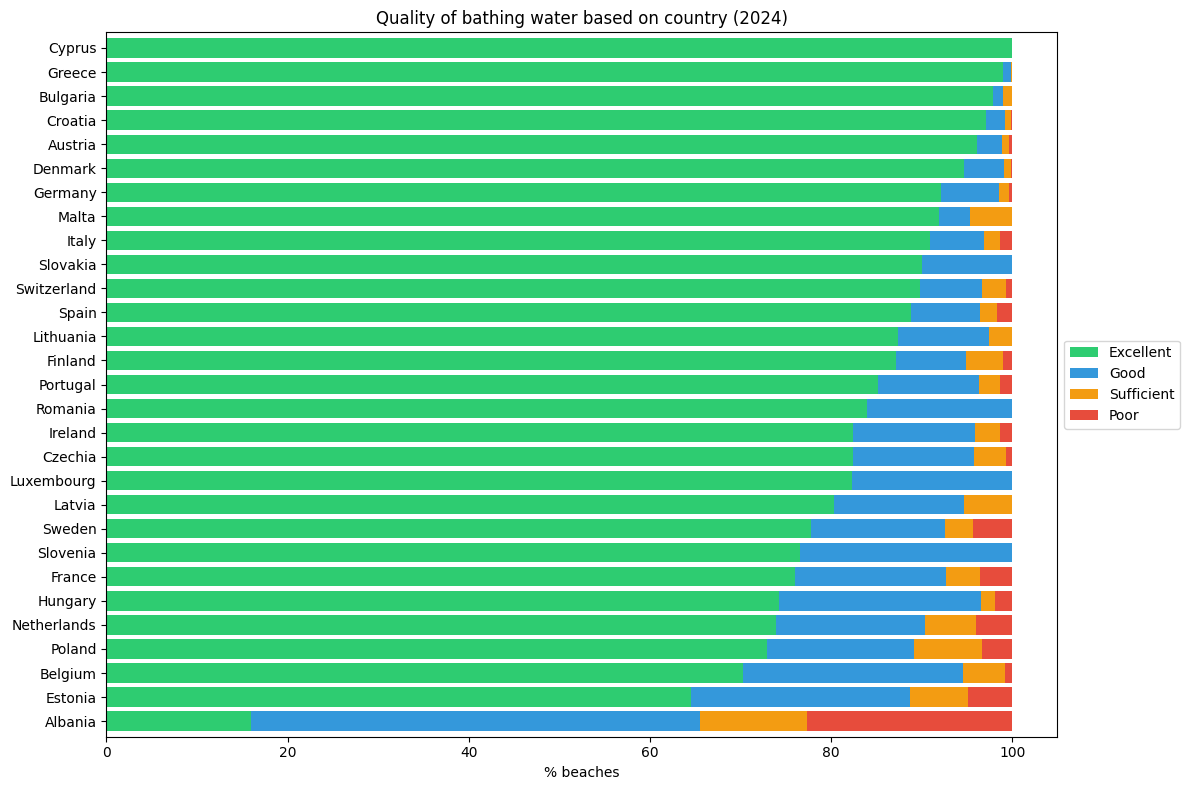

In [ ]:
# ============================================================
# BUNKA 6: Bar chart — krajiny podľa % Excellent (2024)
# ============================================================
COUNTRY_NAMES = {
    'AL': 'Albania', 'AT': 'Austria', 'BE': 'Belgium', 'BG': 'Bulgaria',
    'CH': 'Switzerland', 'CY': 'Cyprus', 'CZ': 'Czechia', 'DE': 'Germany',
    'DK': 'Denmark', 'EE': 'Estonia', 'EL': 'Greece', 'ES': 'Spain',
    'FI': 'Finland', 'FR': 'France', 'HR': 'Croatia', 'HU': 'Hungary',
    'IE': 'Ireland', 'IT': 'Italy', 'LT': 'Lithuania', 'LU': 'Luxembourg',
    'LV': 'Latvia', 'ME': 'Montenegro', 'MT': 'Malta', 'NL': 'Netherlands',
    'PL': 'Poland', 'PT': 'Portugal', 'RO': 'Romania', 'SE': 'Sweden',
    'SI': 'Slovenia', 'SK': 'Slovakia', 'UK': 'United Kingdom'
}

df = final_df.dropna(subset=['quality_score']).copy()
df_2024 = df[df['season'] == 2024]

categories = ['Excellent', 'Good', 'Sufficient', 'Poor']
colors     = ['#2ecc71',   '#3498db', '#f39c12',    '#e74c3c']

country_pct = (
    df_2024.groupby(['countryCode', 'quality_label'])
           .size()
           .unstack(fill_value=0)
           .reindex(columns=categories, fill_value=0)
)

country_pct = country_pct.div(country_pct.sum(axis=1), axis=0) * 100
country_pct = country_pct.sort_values('Excellent', ascending=True)

country_pct.index = [COUNTRY_NAMES.get(c, c) for c in country_pct.index]

ax = country_pct.plot(kind='barh', stacked=True, figsize=(12, 8),
                      color=colors, width=0.8)

plt.xlabel("% beaches")
plt.title("Quality of bathing water based on country (2024)")
ax.legend(loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.tight_layout()
plt.savefig("kvalita_podla_typu.png", dpi=300, bbox_inches='tight')
plt.show()

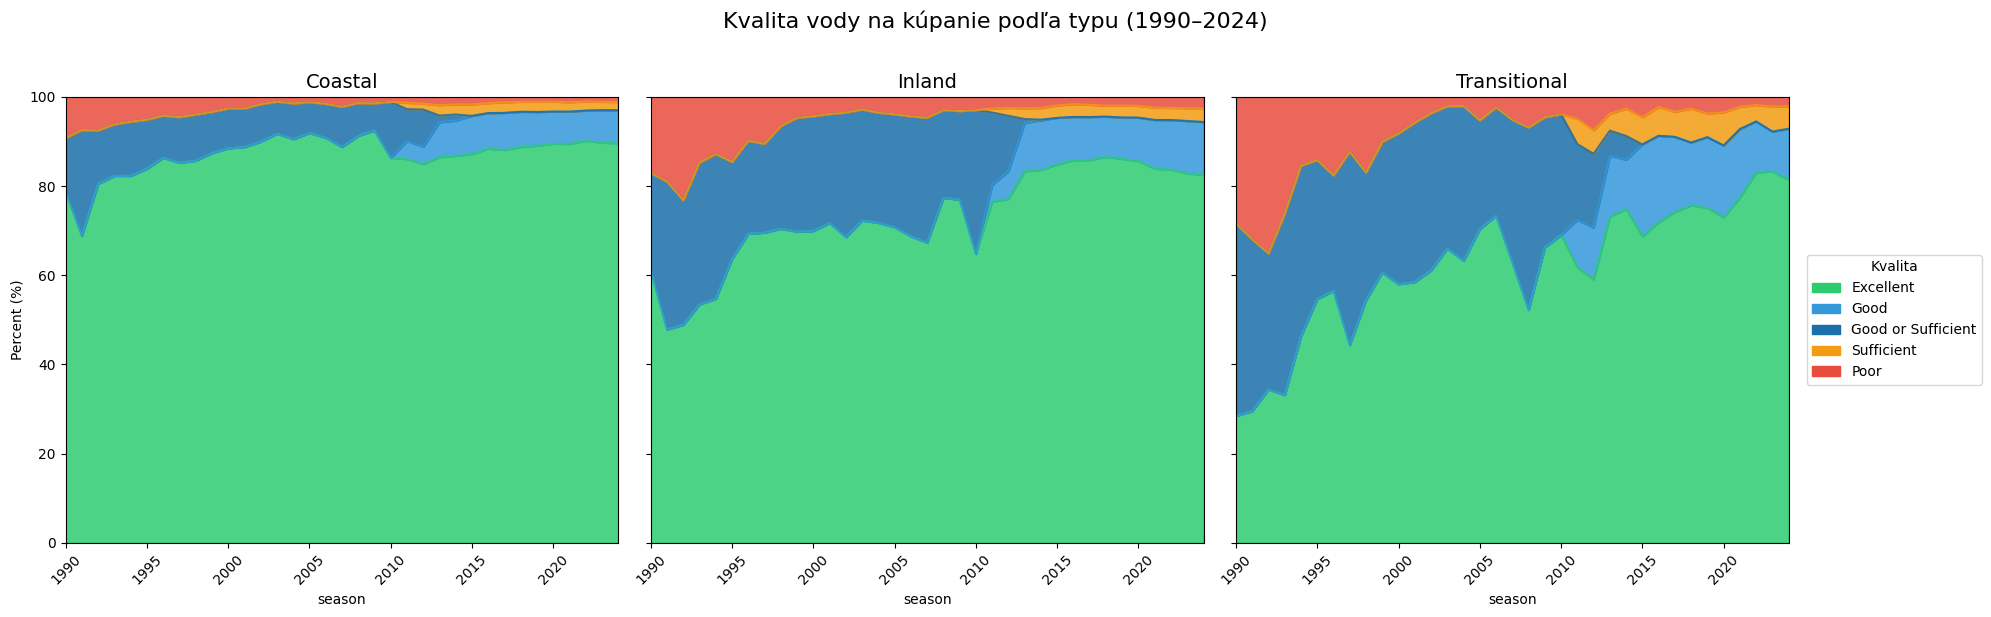

In [ ]:
# ============================================================
# BUNKA 7: Kvalita podľa typu vody v čase (stacked area)
# ============================================================

# Prevodná tabuľka: interné názvy typov vôd → čitateľné kategórie.
# Jazerá aj rieky zlúčime do jednej kategórie 'Inland'.
TYPE_MAP = {
    'coastalBathingWater':      'Coastal',
    'lakeBathingWater':         'Inland',
    'riverBathingWater':        'Inland',
    'transitionalBathingWater': 'Transitional'
}
ORDER  = ['Excellent', 'Good', 'Good or Sufficient', 'Sufficient', 'Poor']
COLORS = ['#2ecc71', '#3498db', '#1a6fa8', '#f39c12', '#e74c3c']

# Preložíme typy vôd a odstránime riadky bez kvalitného hodnotenia
df7 = final_df.dropna(subset=['quality_label']).copy()
df7['bathingWaterType'] = df7['bathingWaterType'].map(TYPE_MAP)

# -------------------------------------------------------
# VÝPOČET PERCENT
# Pre každý rok a typ vody spočítame koľko percent tvorí
# každá kategória kvality.
# groupby + size()        → počet meraní pre každú kombináciu
# transform(x / x.sum()) → vydelíme súčtom v danom roku/type
#                           (transform zachová index = nepríde
#                           o stĺpce pri reset_index nižšie)
# * 100                   → prevedieme na percentá
# -------------------------------------------------------
pct = (
    df7.groupby(['season', 'bathingWaterType', 'quality_label'])
       .size()
       .groupby(level=[0, 1]).transform(lambda x: x / x.sum() * 100)
       .reset_index(name='percent')
)

# -------------------------------------------------------
# GRAFY
# sharey=True → všetky tri grafy zdieľajú Y os (0–100%)
#               takže ich vizuálne ľahšie porovnáme
# -------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, wtype in zip(axes, ['Coastal', 'Inland', 'Transitional']):
    subset = pct[pct['bathingWaterType'] == wtype]

    # Ak pre daný typ nie sú žiadne dáta, skryjeme prázdny graf
    if subset.empty:
        ax.set_visible(False)
        continue

    # pivot → riadky = roky, stĺpce = kategórie kvality
    # reindex → zabezpečí správne poradie stĺpcov a doplní 0
    #           ak niektorá kategória v danom type chýba
    (subset.pivot(index='season', columns='quality_label', values='percent')
           .reindex(columns=ORDER, fill_value=0)
           .plot(kind='area', ax=ax, color=COLORS, alpha=0.85, legend=False))

    ax.set_title(wtype, fontsize=14)
    ax.set_ylabel("Percent (%)" if ax == axes[0] else "")
    ax.set_ylim(0, 100)

    # Zobrazíme len roky deliteľné 5 aby sa popisky neprekrývali
    years = sorted(subset['season'].unique())
    ticks = [y for y in years if y % 5 == 0]
    ax.set_xticks(ticks)
    ax.set_xticklabels(ticks, rotation=45)
    ax.set_xlim(min(years), max(years))

# -------------------------------------------------------
# LEGENDA
# Pridáme ju len k poslednému grafu a posunieme ju
# pomocou bbox_to_anchor za pravý okraj aby neprekrývala dáta.
# Rectangle() vytvorí farebné štvorčeky namiesto čiar
# (area grafy by inak mali v legende čiary, nie plochy).
# -------------------------------------------------------
handles = [plt.Rectangle((0,0), 1, 1, color=c) for c in COLORS]
axes[2].legend(handles, ORDER, title="Kvalita",
               loc='center left', bbox_to_anchor=(1.02, 0.5))

fig.suptitle("Kvalita vody na kúpanie podľa typu (1990–2024)", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("kvalita_vody_podla_typu.png", dpi=300, bbox_inches='tight')
plt.show()

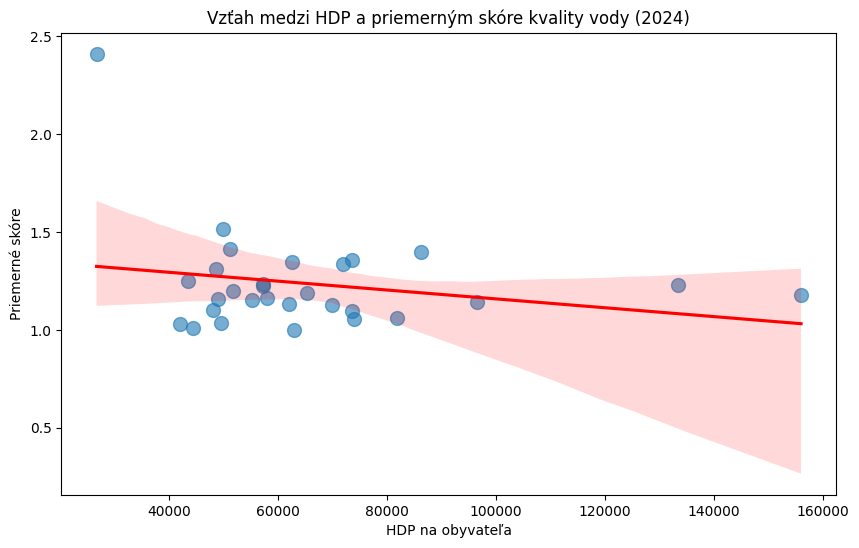

In [ ]:
# ============================================================
# BUNKA 8: Vzťah medzi HDP a kvalitou vody
# ============================================================
plt.figure(figsize=(10, 6))
df_plot = final_df[final_df['season'] == 2024].groupby('countryCode').agg({
    'gdp_pps': 'mean',
    'quality_score': 'mean'
}).dropna()

sns.regplot(data=df_plot, x='gdp_pps', y='quality_score',
            scatter_kws={'s': 100, 'alpha': 0.6}, line_kws={'color': 'red'})
plt.title("Vzťah medzi HDP a priemerným skóre kvality vody (2024)")
plt.xlabel("HDP na obyvateľa")
plt.ylabel("Priemerné skóre")
plt.savefig("HDP.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# BUNKA 9: Porovnanie kvality vody na mape (2 roky vedľa seba)
# ============================================================

def plot_water_quality_comparison(df, year1, year2):
    ORDER  = ['Excellent', 'Good', 'Good or Sufficient', 'Sufficient', 'Poor']
    COLORS = ['#2ecc71', '#3498db', '#1a6fa8', '#f39c12', '#e74c3c']

    # -------------------------------------------------------
    # HLAVNÁ MAPA
    # px.scatter_geo vykreslí body na mape podľa lat/lon.
    # facet_col='season' automaticky rozdelí graf na 2 panely
    # (jeden pre každý rok) vedľa seba.
    # color_discrete_map priradí každej kategórii konkrétnu farbu.
    # category_orders zabezpečí konzistentné poradie farieb/rokov.
    # showlegend=False skryjeme pôvodnú legendu s malými bodkami
    # — nahradíme ju vlastnou s väčšími bodkami nižšie.
    # -------------------------------------------------------
    fig = px.scatter_geo(
        df[df['season'].isin([year1, year2])],
        lat='lat', lon='lon',
        color='quality_label',
        facet_col='season',
        color_discrete_map=dict(zip(ORDER, COLORS)),
        category_orders={'quality_label': ORDER, 'season': [year1, year2]},
        hover_data=['bathingWaterType'],
        width=1500, height=700
    )

    # Zameráme mapu na Európu a zmenšíme bodky na mape
    fig.update_geos(lonaxis_range=[-18, 40], lataxis_range=[20, 70], showcountries=True)
    fig.update_traces(marker_size=3, showlegend=False)

    # -------------------------------------------------------
    # VLASTNÁ LEGENDA S VÄČŠÍMI BODKAMI
    # Plotly neumožňuje priamo zmeniť veľkosť bodiek len v legende.
    # Riešenie: pridáme neviditeľné "dummy" traces (lat/lon=None
    # = žiadny bod sa nevykreslí na mape) len kvôli legende.
    # marker size=12 zabezpečí veľké dobre viditeľné bodky v legende.
    # -------------------------------------------------------
    for label, color in zip(ORDER, COLORS):
        fig.add_trace(go.Scattergeo(
            lat=[None], lon=[None],
            mode='markers',
            marker=dict(size=12, color=color),
            name=label,
            showlegend=True
        ))

    # -------------------------------------------------------
    # ÚPRAVA NADPISOV PANELOV
    # px.scatter_geo automaticky generuje nadpisy vo formáte
    # "season=2000" — for_each_annotation ich preformátuje
    # na čitateľnejší tvar "Rok 2000".
    # split('=')[-1] vezme časť za znakom '=' teda samotný rok.
    # -------------------------------------------------------
    fig.for_each_annotation(lambda a: a.update(text=f"Rok {a.text.split('=')[-1]}"))

    fig.update_layout(
        title=dict(text=f"Porovnanie kvality vody ({year1} vs {year2})",
                   y=0.95, x=0.5, xanchor='center'),
        margin=dict(l=10, r=10, t=80, b=10),
        legend=dict(
            title_text='', x=0.01, y=0.98,
            xanchor='left', yanchor='top',
            bgcolor='rgba(255,255,255,0.8)',
            bordercolor='rgba(0,0,0,0.1)',
            borderwidth=1, font=dict(size=14)
        )
    )
    fig.show()


plot_water_quality_comparison(final_df, 2000, 2024)

In [ ]:
# ============================================================
# BUNKA 10: Choropleth mapa — % Excellent pláží (2024)
# ============================================================

countries = gpd.read_file("https://fmfi-compbio.github.io/viz/data/country_boundaries.geojson")
countries = countries.set_index('ISO3')

ALPHA2_TO_ISO3 = {
    'AL': 'ALB', 'AT': 'AUT', 'BE': 'BEL', 'BG': 'BGR',
    'CH': 'CHE', 'CY': 'CYP', 'CZ': 'CZE', 'DE': 'DEU',
    'DK': 'DNK', 'EE': 'EST', 'EL': 'GRC', 'ES': 'ESP',
    'FI': 'FIN', 'FR': 'FRA', 'HR': 'HRV', 'HU': 'HUN',
    'IE': 'IRL', 'IT': 'ITA', 'LT': 'LTU', 'LU': 'LUX',
    'LV': 'LVA', 'ME': 'MNE', 'MT': 'MLT', 'NL': 'NLD',
    'PL': 'POL', 'PT': 'PR1',
    'RO': 'ROU', 'SE': 'SWE',
    'SI': 'SVN', 'SK': 'SVK', 'UK': 'GBR'
}

map_df = (
    final_df[final_df['season'] == 2024]
    .dropna(subset=['quality_score'])
    .groupby('countryCode')
    .apply(lambda x: (x['quality_score'] == 1).sum() / len(x) * 100, include_groups=False)
    .reset_index(name='pct_excellent')
)
map_df['ISO3'] = map_df['countryCode'].map(ALPHA2_TO_ISO3)

countries2 = countries.copy(deep=True)
countries2['pct_excellent'] = map_df.set_index('ISO3')['pct_excellent']

# Vykreslenie mapy bez defaultného nadpisu
fig = px.choropleth(
    countries2,
    geojson=countries2.geometry,
    locations=countries2.index,
    color='pct_excellent',
    range_color=(0, 100),
    color_continuous_scale='RdYlGn',
    labels={'pct_excellent': '% Excellent'},
    hover_name='Name'
)

# 1. ZAMERANIE NA EURÓPU
fig.update_geos(
    lonaxis_range=[-20, 45],  # Zemepisná dĺžka (odrezanie Atlantiku a Ázie)
    lataxis_range=[30, 72],   # Zemepisná šírka (odrezanie Afriky a ďalekého severu)
    visible=True,
    showcoastlines=True,
    coastlinecolor='gray',
    showland=True,
    landcolor='lightgray',
    showframe=False,
    showcountries=True,
    countrycolor='white'
)

# 2. ÚPRAVA ROZLOŽENIA A LEGENDY
fig.update_layout(
    height=600,
    width=1100,
    margin={"r": 80, "t": 60, "l": 0, "b": 0},

    # Nastavenie vycentrovaného nadpisu
    title={
        'text': '% Excellent vôd v Európe (2024)',
        'y': 0.95,
        'x': 0.45,
        'xanchor': 'center'
    },

    # Umiestnenie legendy MIMO mapy
    coloraxis_colorbar=dict(
        title="% Excellent",
        x=1.02,
        xanchor='left',
        y=0.5,
        len=0.75,
        thickness=15
    )
)

fig.show()

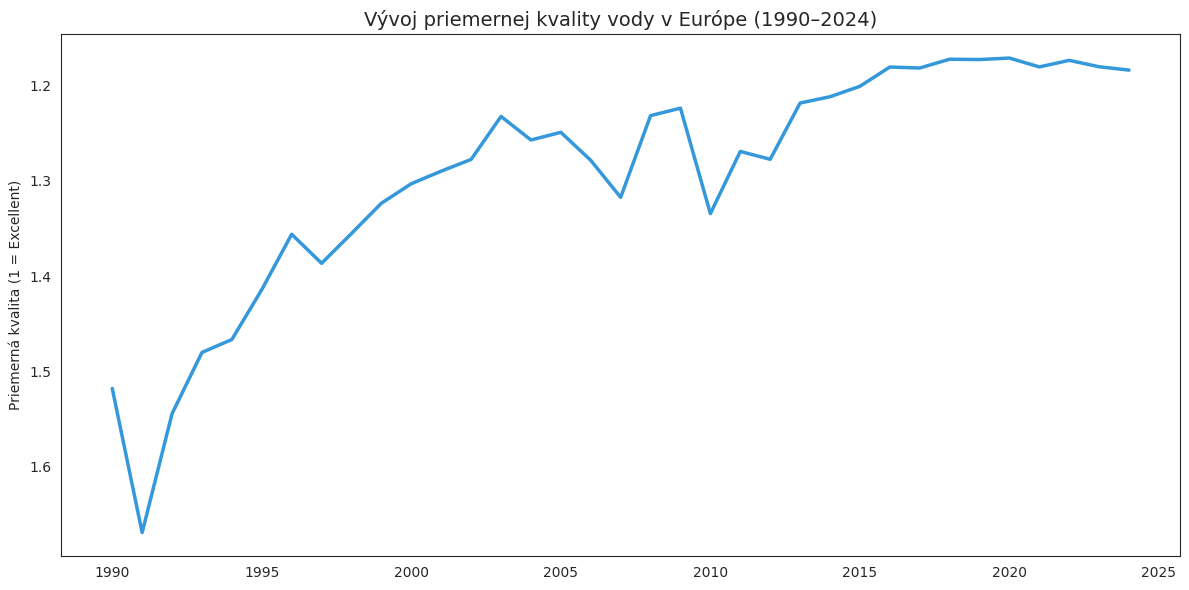

In [ ]:
# ============================================================
# BUNKA 11: Priemerná kvalita vody (1990 - 2024)
# ============================================================
yearly_trend = final_df.groupby('season')['quality_score'].mean().reset_index()

sns.set_style("white")

plt.figure(figsize=(12, 6))
sns.lineplot(data=yearly_trend, x='season', y='quality_score', color='#3498db', linewidth=2.5)
plt.gca().invert_yaxis()
plt.title("Vývoj priemernej kvality vody v Európe (1990–2024)", fontsize=14)
plt.xlabel("")
plt.ylabel("Priemerná kvalita (1 = Excellent)")
plt.tight_layout()
plt.savefig("Vyvoj_kvality.png", dpi=300, bbox_inches='tight')
plt.show()

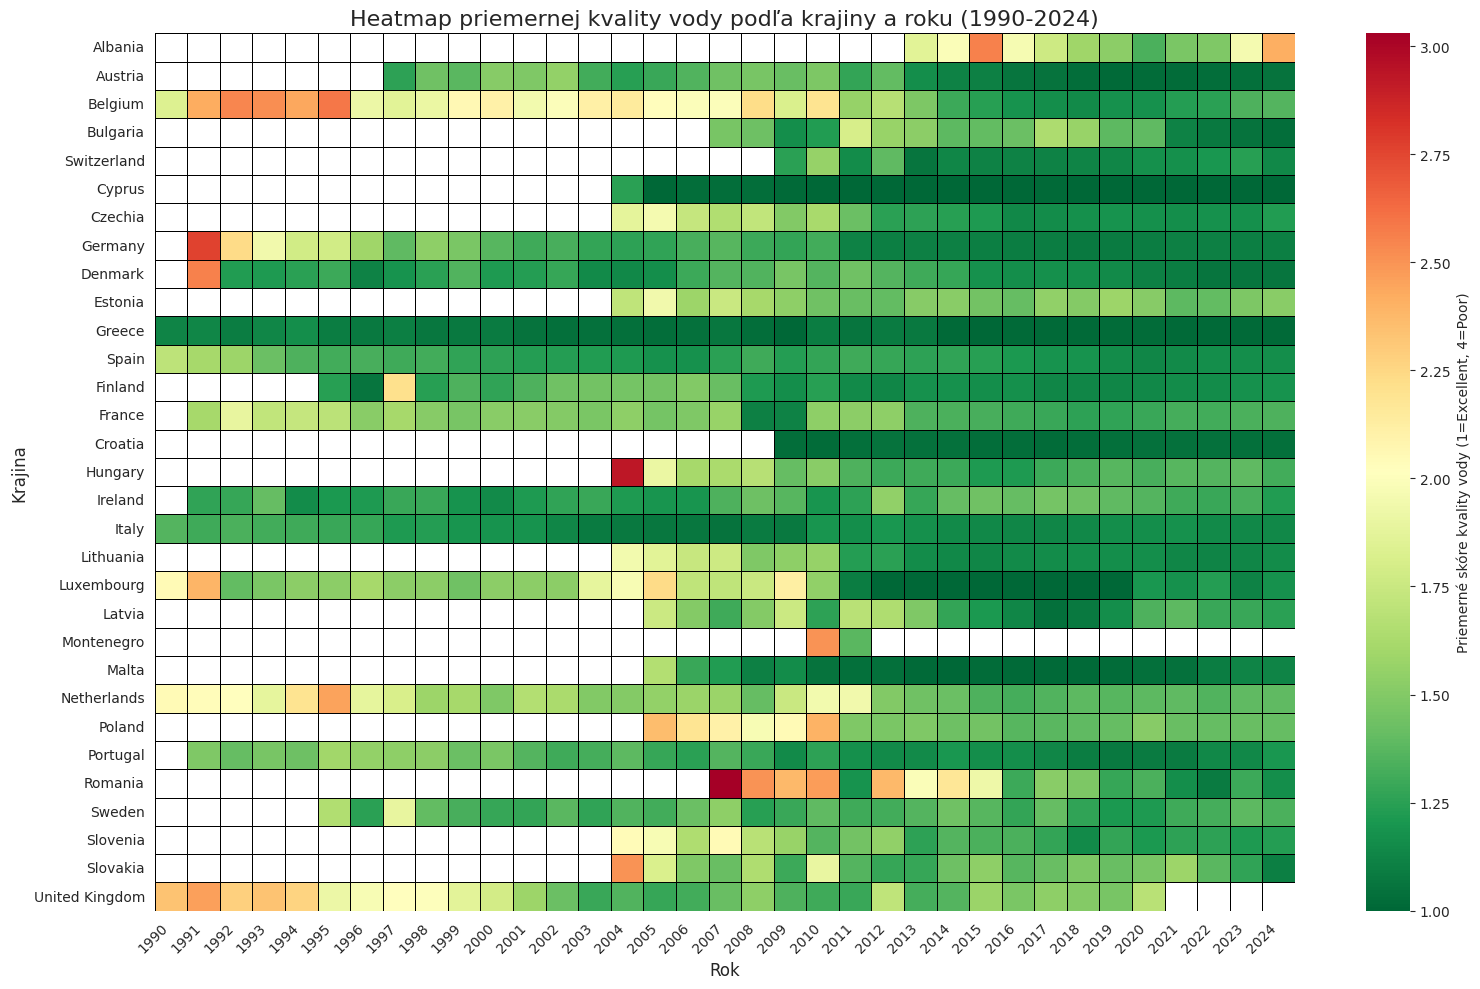

In [ ]:
# ============================================================
# BUNKA 12: Heatmap priemernej kvality vody podľa krajiny a roku
# ============================================================

# Vypočítame priemerné skóre kvality pre každú krajinu a rok
average_quality_by_country_year = final_df.groupby(['season', 'countryCode'])['quality_score'].mean().unstack()

# Mapujeme kódy krajín na celé názvy pre lepšiu čitateľnosť
# Používame COUNTRY_NAMES definované v BUNKA 6
average_quality_by_country_year.columns = [COUNTRY_NAMES.get(c, c) for c in average_quality_by_country_year.columns]

plt.figure(figsize=(16, 10))
sns.heatmap(
    average_quality_by_country_year.T, # Transponujeme pre roky na x-ovej osi a krajiny na y-ovej
    cmap='RdYlGn_r', # Obrátená farebná škála, kde zelená je dobrá (nižšie skóre) a červená zlá (vyššie skóre)
    linewidths=0.5,
    linecolor='black',
    cbar_kws={'label': 'Priemerné skóre kvality vody (1=Excellent, 4=Poor)'},
    annot=False
)

plt.title('Heatmap priemernej kvality vody podľa krajiny a roku (1990-2024)', fontsize=16)
plt.xlabel('Rok', fontsize=12)
plt.ylabel('Krajina', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# BUNKA 13: Import a spracovanie dát o pobrežnom turizme
# ============================================================
TOURISM_FILENAME = "tour_occ_ninatdc__custom_21154463_linear_2_0.csv"

url_tourism = BASE_RAW + TOURISM_FILENAME
df_tour = pd.read_csv(url_tourism)

df_tour_clean = df_tour[['geo', 'TIME_PERIOD', 'OBS_VALUE']].copy()

# Bezpečná konverzia hodnôt na čísla (prípadné texty ako ':' zmení na NaN)
df_tour_clean['OBS_VALUE'] = pd.to_numeric(df_tour_clean['OBS_VALUE'], errors='coerce')

# Premenovanie stĺpcov na názvy, ktoré používame vo final_df
df_tour_clean.rename(columns={
    'geo': 'countryCode',
    'TIME_PERIOD': 'season',
    'OBS_VALUE': 'coastal_tourism_nights'
}, inplace=True)

# Ak stĺpec už existuje (napr. pri opakovanom spustení bunky), odstránime ho
if 'coastal_tourism_nights' in final_df.columns:
    final_df = final_df.drop(columns=['coastal_tourism_nights'])

# Spojenie s hlavným datasetom final_df
final_df = pd.merge(
    final_df,
    df_tour_clean,
    on=['countryCode', 'season'],
    how='left'
)

print(f"Aktuálny počet stĺpcov: {len(final_df.columns)}\n")

Aktuálny počet stĺpcov: 18



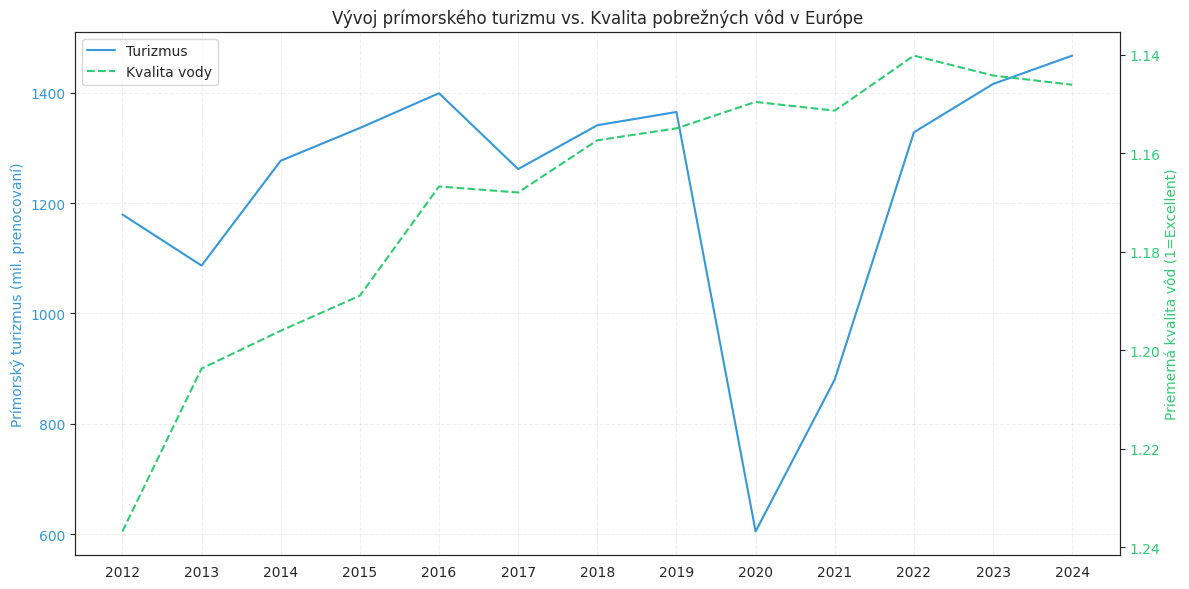

In [ ]:
# ============================================================
# BUNKA 14: Vývoj pobrežného turizmu a kvality vôd v čase
# ============================================================

# Trend turizmu (súčet za Európu) a kvality pobrežných vôd v čase
tour_trend = (
    final_df[['countryCode', 'season', 'coastal_tourism_nights']]
    .drop_duplicates()
    .groupby('season')['coastal_tourism_nights']
    .sum()
    .reset_index()
)

qual_trend = (
    final_df[final_df['bathingWaterType'].str.contains('coast', case=False, na=False)]
    .groupby('season')['quality_score']
    .mean()
    .reset_index()
)

# Spojenie a filtrovanie len rokov s turistickými dátami
trend_df = (
    pd.merge(tour_trend, qual_trend, on='season')
    .query('coastal_tourism_nights > 0')
    .assign(tourism_mil=lambda x: x['coastal_tourism_nights'] / 1_000_000)
)

# Dvojosový graf: turizmus (ľavá os) + kvalita vody (pravá os, obrátená)
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.plot(trend_df['season'], trend_df['tourism_mil'], color='#3498db', label='Turizmus')
ax1.set_ylabel('Prímorský turizmus (mil. prenocovaní)', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')
ax1.set_xticks(trend_df['season'])
ax1.grid(True, linestyle='--', alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(trend_df['season'], trend_df['quality_score'], color='#2ecc71', linestyle='--', label='Kvalita vody')
ax2.set_ylabel('Priemerná kvalita vôd (1=Excellent)', color='#2ecc71')
ax2.tick_params(axis='y', labelcolor='#2ecc71')
ax2.invert_yaxis()

# Spoločná legenda
lines = ax1.get_lines() + ax2.get_lines()
ax1.legend(lines, [l.get_label() for l in lines], loc='upper left')

plt.title('Vývoj prímorského turizmu vs. Kvalita pobrežných vôd v Európe')
plt.tight_layout()
plt.savefig("kvalita_vody_po_rokoch.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# BUNKA 15: Analýza krajiny — kvalita podľa typu + porovnanie máp
# ============================================================

def analyze_country(country_code, year1=None, year2=None):
    cc   = country_code.upper()
    df_c = final_df[final_df['countryCode'] == cc].copy()
    if df_c.empty:
        print(f"Krajina '{cc}' nenájdená.")
        return

    # Ak roky nie sú zadané, automaticky vyberieme prvý a posledný dostupný rok
    name  = COUNTRY_NAMES.get(cc, cc)
    years = sorted(df_c['season'].unique())
    year1 = year1 or years[0]
    year2 = year2 or years[-1]

    ORDER  = ['Excellent', 'Good', 'Good or Sufficient', 'Sufficient', 'Poor']
    COLORS = ['#2ecc71', '#3498db', '#1a6fa8', '#f39c12', '#e74c3c']
    TYPES  = ['Coastal', 'Inland', 'Transitional']

    # Prevodná tabuľka z Eurostat kódov na ISO3 — Choropleth vyžaduje ISO3 formát
    ALPHA2_TO_ISO3 = {
        'AL':'ALB','AT':'AUT','BE':'BEL','BG':'BGR','CH':'CHE','CY':'CYP',
        'CZ':'CZE','DE':'DEU','DK':'DNK','EE':'EST','EL':'GRC','ES':'ESP',
        'FI':'FIN','FR':'FRA','HR':'HRV','HU':'HUN','IE':'IRL','IT':'ITA',
        'LT':'LTU','LU':'LUX','LV':'LVA','ME':'MNE','MT':'MLT','NL':'NLD',
        'PL':'POL','PT':'PRT','RO':'ROU','SE':'SWE','SI':'SVN','SK':'SVK','UK':'GBR'
    }

    # Preložíme interné názvy typov vôd na čitateľné kategórie
    df_c['waterType'] = df_c['bathingWaterType'].map(TYPE_MAP)

    # Pre mapy potrebujeme len riadky s known kvalitou aj koordinátmi
    df_all = df_c[df_c['quality_label'].notna() & df_c['lat'].notna()]

    # -------------------------------------------------------
    # VÝPOČET PERCENT PRE STACKED AREA GRAFY
    # groupby + size()        → počet meraní pre každú kombináciu
    # transform(x / x.sum()) → percentuálny podiel v danom roku/type
    # -------------------------------------------------------
    pct = (
        df_c.dropna(subset=['quality_label'])
        .groupby(['season', 'waterType', 'quality_label']).size()
        .groupby(level=[0, 1]).transform(lambda x: x / x.sum() * 100)
        .reset_index(name='pct')
    )

    # -------------------------------------------------------
    # LAYOUT: 6-stĺpcový grid
    # Riadok 1: 3 grafy, každý colspan=2
    # Riadok 2: 2 mapy, každá colspan=3
    # row_heights → mapy zaberajú 70% výšky
    # -------------------------------------------------------
    fig = make_subplots(
        rows=2, cols=6,
        specs=[
            [{"type":"xy","colspan":2}, None, {"type":"xy","colspan":2}, None, {"type":"xy","colspan":2}, None],
            [{"type":"geo","colspan":3}, None, None, {"type":"geo","colspan":3}, None, None],
        ],
        subplot_titles=TYPES + [str(year1), str(year2)],
        row_heights=[0.3, 0.7],
        vertical_spacing=0.08,
        horizontal_spacing=0.02
    )

    # -------------------------------------------------------
    # RIADOK 1: STACKED AREA GRAFY
    # fill='tonexty' + stackgroup → vrstvy sa skladajú na seba
    # reindex → doplní 0 pre roky kde daná kategória chýba
    # showlegend len pre prvý graf aby sa legenda nezobrazila 3x
    # -------------------------------------------------------
    for idx, (col, wtype) in enumerate(zip([1, 3, 5], TYPES)):
        subset = pct[pct['waterType'] == wtype]
        for quality, color in zip(ORDER, COLORS):
            y = (subset[subset['quality_label'] == quality]
                 .set_index('season')['pct']
                 .reindex(years, fill_value=0))
            fig.add_trace(go.Scatter(
                x=y.index, y=y.values, name=quality,
                fill='tonexty', fillcolor=color, line=dict(color=color, width=0),
                stackgroup='one', legendgroup=quality, showlegend=(idx == 0)
            ), row=1, col=col)

    # -------------------------------------------------------
    # RIADOK 2: MAPY
    # bounds → rozsah súradníc krajiny + 2° rezerva okolo
    # Choropleth → vyfarbi krajinu na šedo pomocou ISO3 kódu
    # Ak rok nemá dáta, df_q bude prázdny a Plotly nič nevykreslí
    # -------------------------------------------------------
    bounds = dict(
        lonaxis_range=[df_all['lon'].min()-2, df_all['lon'].max()+2],
        lataxis_range=[df_all['lat'].min()-2, df_all['lat'].max()+2],
    )
    geo_settings = dict(showland=True, landcolor='white', showcountries=True,
                        showcoastlines=True, coastlinecolor='gray', showframe=False)

    for map_col, yr in [(1, year1), (4, year2)]:
        fig.add_trace(go.Choropleth(
            locations=[ALPHA2_TO_ISO3.get(cc)], z=[1],
            colorscale=[[0,'#d0d0d0'],[1,'#d0d0d0']],
            showscale=False, showlegend=False, hoverinfo='skip'
        ), row=2, col=map_col)

        df_m = df_all[df_all['season'] == yr]
        for quality, color in zip(ORDER, COLORS):
            df_q = df_m[df_m['quality_label'] == quality]
            fig.add_trace(go.Scattergeo(
                lat=df_q['lat'], lon=df_q['lon'], mode='markers',
                marker=dict(size=8, color=color), name=quality,
                legendgroup=quality, showlegend=False,
                hovertemplate=f"<b>{quality}</b><br>%{{text}}<extra></extra>",
                text=df_q['bathingWaterType']
            ), row=2, col=map_col)

    # 'geo' = prvá mapa, 'geo2' = druhá — Plotly ich čísluje automaticky
    for geo_id in ['geo', 'geo2']:
        fig.update_layout(**{geo_id: {**geo_settings, **bounds}})

    fig.update_yaxes(range=[0, 100], row=1)
    fig.update_layout(
        title=dict(text=f"Kvalita vody — {name} ({year1} vs {year2})",
                   font=dict(size=16), x=0.5, xanchor='center'),
        height=1050, width=1400,
        legend=dict(x=1.01, y=0.95, xanchor='left', yanchor='top',
                    bgcolor='rgba(255,255,255,0.8)',
                    bordercolor='rgba(0,0,0,0.15)', borderwidth=1, font=dict(size=12))
    )
    fig.show()


analyze_country('SK', 2000, 2024)